In [1]:
import pandas as pd

df = pd.read_csv("oil_platform_generator_optimization_synthetic_15057.csv")

print(df.head())
print(df.shape)
print(df.info())

   g1_load_pct  g2_load_pct  g3_load_pct  g4_load_pct  g1_power_kw  \
0    66.970211    51.678913    93.243943    81.648296   803.642527   
1    45.433581    40.664230     0.000000    63.927786   545.202968   
2    62.758061    37.743958    74.755642    58.396582   753.096727   
3     0.000000    76.959735    75.000546    47.649791     0.000000   
4          NaN    71.957739     0.000000    80.208929   302.584500   

   g2_power_kw  g3_power_kw  g4_power_kw  platform_demand_kw  \
0   620.146952   932.439431   816.482964         2764.046221   
1   487.970758     0.000000          NaN         1338.903868   
2   452.927501   747.556421   583.965818         2456.722906   
3   923.516816   750.005464   476.497912         1972.420966   
4   863.492871     0.000000   802.089287         1927.805369   

   ambient_temperature_c  sea_temperature_c  humidity_pct  wind_speed_mps  \
0              10.000000          19.199307           NaN             NaN   
1              22.229002          22.624

In [3]:
print(df.describe())

        g1_load_pct   g2_load_pct   g3_load_pct   g4_load_pct   g1_power_kw  \
count  14522.000000  14445.000000  14568.000000  14530.000000  14504.000000   
mean      52.988113     51.809475     52.925261     52.022270    635.682235   
std       25.743077     24.901501     25.132633     25.550206    308.060600   
min       -1.209496     -1.298047     -1.146243     -1.449712    -14.615697   
25%       41.756630     41.243477     41.620790     40.901712    501.718915   
50%       58.110833     56.490128     57.252155     56.644674    695.579841   
75%       70.578828     68.563574     70.143366     69.289804    847.662577   
max       96.121228     95.931424     95.899139     96.022765   1155.625474   

        g2_power_kw   g3_power_kw   g4_power_kw  platform_demand_kw  \
count  14518.000000  14557.000000  14588.000000        14480.000000   
mean     623.779865    526.611056    519.207764         2026.627370   
std      298.732397    253.319987    256.357890          508.570316   
min 

In [4]:
df.isnull().sum()

,0
g1_load_pct,535
g2_load_pct,612
g3_load_pct,489
g4_load_pct,527
g1_power_kw,553
g2_power_kw,539
g3_power_kw,500
g4_power_kw,469
platform_demand_kw,577
ambient_temperature_c,575


In [5]:
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": (missing / len(df)) * 100
})

print(missing_table)

                                 Missing Values  Missing %
g1_load_pct                                 535   3.553165
g2_load_pct                                 612   4.064555
g3_load_pct                                 489   3.247659
g4_load_pct                                 527   3.500033
g1_power_kw                                 553   3.672710
g2_power_kw                                 539   3.579730
g3_power_kw                                 500   3.320715
g4_power_kw                                 469   3.114830
platform_demand_kw                          577   3.832105
ambient_temperature_c                       575   3.818822
sea_temperature_c                           514   3.413695
humidity_pct                                516   3.426977
wind_speed_mps                              513   3.407053
g1_status                                     0   0.000000
g2_status                                     0   0.000000
g3_status                                     0   0.0000

In [6]:
for i in range(1, 5):
    print(f"\nGenerator {i}")

    print(
        df.groupby(f"g{i}_status")[
            [f"g{i}_load_pct", f"g{i}_power_kw"]
        ].apply(lambda x: x.isnull().sum())
    )


Generator 1
           g1_load_pct  g1_power_kw
g1_status                          
OFF                 38           62
ON                 497          491

Generator 2
           g2_load_pct  g2_power_kw
g2_status                          
OFF                 53           65
ON                 559          474

Generator 3
           g3_load_pct  g3_power_kw
g3_status                          
OFF                103           34
ON                 386          466

Generator 4
           g4_load_pct  g4_power_kw
g4_status                          
OFF                 90           42
ON                 437          427


In [7]:
for i in range(1, 5):

    load_missing = df[f"g{i}_load_pct"].isnull()

    print(f"\nGenerator {i}")
    print(
        df.loc[load_missing, f"g{i}_status"]
        .value_counts()
    )


Generator 1
g1_status
ON     497
OFF     38
Name: count, dtype: int64

Generator 2
g2_status
ON     559
OFF     53
Name: count, dtype: int64

Generator 3
g3_status
ON     386
OFF    103
Name: count, dtype: int64

Generator 4
g4_status
ON     437
OFF     90
Name: count, dtype: int64


In [8]:
for i in range(1, 5):

    status = f"g{i}_status"
    load = f"g{i}_load_pct"
    power = f"g{i}_power_kw"

    print(f"\n========== G{i} ==========")

    print("Status vs missing LOAD:")
    print(
        pd.crosstab(
            df[status],
            df[load].isnull()
        )
    )

    print("\nStatus vs missing POWER:")
    print(
        pd.crosstab(
            df[status],
            df[power].isnull()
        )
    )


========== G1 ==========
Status vs missing LOAD:
g1_load_pct  False  True 
g1_status                
OFF           1891     38
ON           12631    497

Status vs missing POWER:
g1_power_kw  False  True 
g1_status                
OFF           1867     62
ON           12637    491

========== G2 ==========
Status vs missing LOAD:
g2_load_pct  False  True 
g2_status                
OFF           1809     53
ON           12636    559

Status vs missing POWER:
g2_power_kw  False  True 
g2_status                
OFF           1797     65
ON           12721    474

========== G3 ==========
Status vs missing LOAD:
g3_load_pct  False  True 
g3_status                
OFF           1728    103
ON           12840    386

Status vs missing POWER:
g3_power_kw  False  True 
g3_status                
OFF           1797     34
ON           12760    466

========== G4 ==========
Status vs missing LOAD:
g4_load_pct  False  True 
g4_status                
OFF           1815     90
ON           12715  

In [9]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicates:", df.duplicated().sum())

Rows: 15057
Columns: 18
Duplicates: 4


In [10]:
power_cols = [
    "g1_power_kw",
    "g2_power_kw",
    "g3_power_kw",
    "g4_power_kw"
]

df["total_generator_power_kw"] = df[power_cols].sum(axis=1)

df["power_difference"] = (
    df["total_generator_power_kw"]
    - df["platform_demand_kw"]
)

print(
    df[
        [
            "platform_demand_kw",
            "total_generator_power_kw",
            "power_difference"
        ]
    ].describe()
)

       platform_demand_kw  total_generator_power_kw  power_difference
count        14480.000000              15057.000000      14480.000000
mean          2026.627370               2225.944825        202.704187
std            508.570316                588.861159        284.988815
min            281.842142                272.163304      -1290.930839
25%           1681.484552               1820.244707        102.916616
50%           2043.096294               2272.922843        237.595368
75%           2380.530653               2651.056740        382.447043
max           3481.686542               3811.286718        789.691035


In [12]:
df.fillna(df.median(numeric_only=True))

,g1_load_pct,g2_load_pct,g3_load_pct,g4_load_pct,g1_power_kw,g2_power_kw,g3_power_kw,g4_power_kw,platform_demand_kw,ambient_temperature_c,sea_temperature_c,humidity_pct,wind_speed_mps,g1_status,g2_status,g3_status,g4_status,daily_diesel_consumption_litres,total_generator_power_kw,power_difference
0,66.970211,51.678913,93.243943,81.648296,803.642527,620.146952,932.439431,816.482964,2764.046221,10.000000,19.199307,72.552651,7.355344,ON,ON,ON,ON,5354.410579,3172.711875,408.665654
1,45.433581,40.664230,0.000000,63.927786,545.202968,487.970758,0.000000,566.032199,1338.903868,22.229002,22.624747,66.595790,2.037037,ON,ON,OFF,ON,4143.158301,1033.173726,-305.730142
2,62.758061,37.743958,74.755642,58.396582,753.096727,452.927501,747.556421,583.965818,2456.722906,24.882936,11.808405,63.692969,14.979759,ON,ON,ON,ON,4955.238744,2537.546466,80.823560
3,0.000000,76.959735,75.000546,47.649791,0.000000,923.516816,750.005464,476.497912,1972.420966,20.378026,16.937063,72.552651,14.516965,OFF,ON,ON,ON,5453.685947,2150.020193,177.599227
4,58.110833,71.957739,0.000000,80.208929,302.584500,863.492871,0.000000,802.089287,1927.805369,26.787346,20.680223,73.546701,3.586543,ON,ON,OFF,ON,5040.033331,1968.166657,40.361289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15052,57.554546,49.518066,68.802299,53.440997,688.667220,589.214324,695.010875,541.957201,2142.457121,27.856139,20.171874,87.430895,10.950516,ON,ON,ON,ON,4457.763559,2514.849619,372.392499
15053,-0.779418,0.410175,62.675060,90.520806,1.470234,-1.910570,627.937321,894.885254,1496.955465,18.015525,15.770467,95.127728,3.141452,OFF,OFF,ON,ON,5295.773187,1522.382240,25.426775
15054,37.429912,67.735390,57.929979,71.568211,444.324897,812.420890,574.991268,716.788991,2406.526314,25.938471,16.019349,81.689414,7.422917,ON,ON,ON,ON,5291.980994,2548.526046,141.999732
15055,51.815173,63.375680,60.836844,79.345743,617.708853,769.865212,611.432691,790.191384,2295.556930,25.884732,15.477091,70.449862,6.112581,ON,ON,ON,ON,5186.733683,2789.198140,493.641210


In [13]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

In [14]:
for i in range(1, 5):

    status = f"g{i}_status"
    load = f"g{i}_load_pct"
    power = f"g{i}_power_kw"

    print(f"\n========== G{i} ==========")

    print("Status vs missing LOAD:")
    print(
        pd.crosstab(
            df[status],
            df[load].isnull()
        )
    )

    print("\nStatus vs missing POWER:")
    print(
        pd.crosstab(
            df[status],
            df[power].isnull()
        )
    )


========== G1 ==========
Status vs missing LOAD:
g1_load_pct  False
g1_status         
OFF           1929
ON           13128

Status vs missing POWER:
g1_power_kw  False
g1_status         
OFF           1929
ON           13128

========== G2 ==========
Status vs missing LOAD:
g2_load_pct  False
g2_status         
OFF           1862
ON           13195

Status vs missing POWER:
g2_power_kw  False
g2_status         
OFF           1862
ON           13195

========== G3 ==========
Status vs missing LOAD:
g3_load_pct  False
g3_status         
OFF           1831
ON           13226

Status vs missing POWER:
g3_power_kw  False
g3_status         
OFF           1831
ON           13226

========== G4 ==========
Status vs missing LOAD:
g4_load_pct  False
g4_status         
OFF           1905
ON           13152

Status vs missing POWER:
g4_power_kw  False
g4_status         
OFF           1905
ON           13152


In [15]:
print(df.isnull().sum())

g1_load_pct                        0
g2_load_pct                        0
g3_load_pct                        0
g4_load_pct                        0
g1_power_kw                        0
g2_power_kw                        0
g3_power_kw                        0
g4_power_kw                        0
platform_demand_kw                 0
ambient_temperature_c              0
sea_temperature_c                  0
humidity_pct                       0
wind_speed_mps                     0
g1_status                          0
g2_status                          0
g3_status                          0
g4_status                          0
daily_diesel_consumption_litres    0
total_generator_power_kw           0
power_difference                   0
dtype: int64


In [16]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [17]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

Rows: 15057
Columns: 20
Duplicate rows: 4


In [18]:
print(df.dtypes)

g1_load_pct                        float64
g2_load_pct                        float64
g3_load_pct                        float64
g4_load_pct                        float64
g1_power_kw                        float64
g2_power_kw                        float64
g3_power_kw                        float64
g4_power_kw                        float64
platform_demand_kw                 float64
ambient_temperature_c              float64
sea_temperature_c                  float64
humidity_pct                       float64
wind_speed_mps                     float64
g1_status                           object
g2_status                           object
g3_status                           object
g4_status                           object
daily_diesel_consumption_litres    float64
total_generator_power_kw           float64
power_difference                   float64
dtype: object


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
g1_load_pct,15057.0,53.170132,25.299343,-1.209496,42.640793,58.110833,70.165245,96.121228
g2_load_pct,15057.0,51.999722,24.407657,-1.298047,42.232992,56.490128,67.936863,95.931424
g3_load_pct,15057.0,53.065784,24.733022,-1.146243,42.517130,57.252155,69.724085,95.899139
g4_load_pct,15057.0,52.184056,25.113434,-1.449712,41.644022,56.644674,68.773760,96.022765
g1_power_kw,15057.0,637.882100,302.560054,-14.615697,511.112376,695.579841,842.190642,1155.625474
g2_power_kw,15057.0,625.783795,293.520724,-15.483142,507.639086,679.759793,818.242151,1153.006478
g3_power_kw,15057.0,528.096717,249.207147,-12.846724,421.431429,571.350261,694.904599,960.116389
g4_power_kw,15057.0,520.666266,252.464563,-13.094376,416.023686,566.032199,688.318656,960.938153
platform_demand_kw,15057.0,2027.258476,498.740016,281.842142,1698.605368,2043.096294,2363.419146,3481.686542
ambient_temperature_c,15057.0,24.942041,4.838157,9.830551,21.825935,25.048073,28.057852,40.130438


In [20]:
load_cols = [
    "g1_load_pct",
    "g2_load_pct",
    "g3_load_pct",
    "g4_load_pct"
]

for col in load_cols:
    print(
        col,
        "Min =", df[col].min(),
        "Max =", df[col].max()
    )

g1_load_pct Min = -1.2094956852532528 Max = 96.12122788788383
g2_load_pct Min = -1.2980465648408923 Max = 95.93142357494536
g3_load_pct Min = -1.1462425726152945 Max = 95.89913923956988
g4_load_pct Min = -1.449712080505341 Max = 96.02276548404514


In [21]:
status_cols = [
    "g1_status",
    "g2_status",
    "g3_status",
    "g4_status"
]

for col in status_cols:
    print("\n", col)
    print(df[col].value_counts())


 g1_status
g1_status
ON     13128
OFF     1929
Name: count, dtype: int64

 g2_status
g2_status
ON     13195
OFF     1862
Name: count, dtype: int64

 g3_status
g3_status
ON     13226
OFF     1831
Name: count, dtype: int64

 g4_status
g4_status
ON     13152
OFF     1905
Name: count, dtype: int64


In [22]:
load_cols = [
    "g1_load_pct",
    "g2_load_pct",
    "g3_load_pct",
    "g4_load_pct"
]

for col in load_cols:
    print(
        col,
        "negative values:",
        (df[col] < 0).sum()
    )

g1_load_pct negative values: 864
g2_load_pct negative values: 772
g3_load_pct negative values: 746
g4_load_pct negative values: 798


In [23]:
power_cols = [
    "g1_power_kw",
    "g2_power_kw",
    "g3_power_kw",
    "g4_power_kw"
]

for col in power_cols:
    print(
        col,
        "negative values:",
        (df[col] < 0).sum()
    )

g1_power_kw negative values: 837
g2_power_kw negative values: 835
g3_power_kw negative values: 776
g4_power_kw negative values: 826


In [24]:
df.loc[
    df["power_difference"].idxmin(),
    [
        "platform_demand_kw",
        "total_generator_power_kw",
        "power_difference",
        "g1_status",
        "g2_status",
        "g3_status",
        "g4_status"
    ]
]

,10501
platform_demand_kw,3116.436146
total_generator_power_kw,1825.505307
power_difference,-1290.930839
g1_status,ON
g2_status,ON
g3_status,ON
g4_status,ON


In [25]:
status_summary = pd.DataFrame({
    "Generator": ["G1", "G2", "G3", "G4"],
    "ON": [
        (df["g1_status"] == "ON").sum(),
        (df["g2_status"] == "ON").sum(),
        (df["g3_status"] == "ON").sum(),
        (df["g4_status"] == "ON").sum()
    ],
    "OFF": [
        (df["g1_status"] == "OFF").sum(),
        (df["g2_status"] == "OFF").sum(),
        (df["g3_status"] == "OFF").sum(),
        (df["g4_status"] == "OFF").sum()
    ]
})

status_summary["ON %"] = (
    status_summary["ON"] / len(df) * 100
)

print(status_summary)

  Generator     ON   OFF       ON %
0        G1  13128  1929  87.188683
1        G2  13195  1862  87.633659
2        G3  13226  1831  87.839543
3        G4  13152  1905  87.348077


In [26]:
status_cols = [
    "g1_status",
    "g2_status",
    "g3_status",
    "g4_status"
]

df["num_generators_on"] = (
    df[status_cols] == "ON"
).sum(axis=1)

print(
    df["num_generators_on"]
    .value_counts()
    .sort_index()
)

num_generators_on
1     110
2    1014
3    5169
4    8764
Name: count, dtype: int64


In [27]:
generator_count_analysis = (
    df.groupby("num_generators_on")
      ["daily_diesel_consumption_litres"]
      .agg(
          ["count", "mean", "median", "min", "max"]
      )
)

print(generator_count_analysis)

                   count         mean       median          min          max
num_generators_on                                                           
1                    110  4348.920569  4317.173194  3460.605735  5600.450873
2                   1014  4788.396222  4778.535663  3286.661154  5973.380876
3                   5169  4912.588776  4931.464172  3690.110933  6165.521461
4                   8764  5016.729702  5006.804310  3943.772895  6197.176777


In [29]:
load_cols = ["g1_load_pct", "g2_load_pct", "g3_load_pct", "g4_load_pct"]
status_cols = ["g1_status", "g2_status", "g3_status", "g4_status"]

for load, status in zip(load_cols, status_cols):
    print("\n", load)
    print(
        df[df[load] < 0][status].value_counts()
    )


 g1_load_pct
g1_status
OFF    864
Name: count, dtype: int64

 g2_load_pct
g2_status
OFF    772
Name: count, dtype: int64

 g3_load_pct
g3_status
OFF    746
Name: count, dtype: int64

 g4_load_pct
g4_status
OFF    798
Name: count, dtype: int64


In [30]:
power_cols = ["g1_power_kw", "g2_power_kw", "g3_power_kw", "g4_power_kw"]

for power, status in zip(power_cols, status_cols):
    print("\n", power)
    print(
        df[df[power] < 0][status].value_counts()
    )


 g1_power_kw
g1_status
OFF    837
Name: count, dtype: int64

 g2_power_kw
g2_status
OFF    835
Name: count, dtype: int64

 g3_power_kw
g3_status
OFF    776
Name: count, dtype: int64

 g4_power_kw
g4_status
OFF    826
Name: count, dtype: int64


In [31]:
diesel_by_generators = (
    df.groupby("num_generators_on")["daily_diesel_consumption_litres"]
      .agg(["count", "mean", "median", "min", "max"])
)

print(diesel_by_generators)

                   count         mean       median          min          max
num_generators_on                                                           
1                    110  4348.920569  4317.173194  3460.605735  5600.450873
2                   1014  4788.396222  4778.535663  3286.661154  5973.380876
3                   5169  4912.588776  4931.464172  3690.110933  6165.521461
4                   8764  5016.729702  5006.804310  3943.772895  6197.176777


In [32]:
df["demand_band"] = pd.cut(
    df["platform_demand_kw"],
    bins=[0, 1000, 1500, 2000, 2500, 3000, 3500, 4000]
)

demand_analysis = (
    df.groupby(
        ["demand_band", "num_generators_on"],
        observed=True
    )["daily_diesel_consumption_litres"]
    .mean()
)

print(demand_analysis)

demand_band   num_generators_on
(0, 1000]     1                    4251.235549
              2                    4280.488797
              3                    3916.437786
(1000, 1500]  2                    4870.031202
              3                    4420.353346
              4                    4185.307821
(1500, 2000]  2                    5467.106043
              3                    4954.065043
              4                    4614.574417
(2000, 2500]  1                    5594.404570
              2                    4584.905225
              3                    5331.231237
              4                    4971.607716
(2500, 3000]  3                    5822.277013
              4                    5327.903106
(3000, 3500]  4                    5675.899904
Name: daily_diesel_consumption_litres, dtype: float64


In [33]:
for load, status in zip(load_cols, status_cols):
    print("\n", load)
    print(df[df[load] < 0][status].value_counts())


 g1_load_pct
g1_status
OFF    864
Name: count, dtype: int64

 g2_load_pct
g2_status
OFF    772
Name: count, dtype: int64

 g3_load_pct
g3_status
OFF    746
Name: count, dtype: int64

 g4_load_pct
g4_status
OFF    798
Name: count, dtype: int64


In [34]:
print(
    df[
        (df["platform_demand_kw"] > 2000) &
        (df["platform_demand_kw"] <= 2500) &
        (df["num_generators_on"] == 1)
    ][[
        "platform_demand_kw",
        "total_generator_power_kw",
        "power_difference",
        "g1_load_pct",
        "g2_load_pct",
        "g3_load_pct",
        "g4_load_pct",
        "g1_power_kw",
        "g2_power_kw",
        "g3_power_kw",
        "g4_power_kw",
        "g1_status",
        "g2_status",
        "g3_status",
        "g4_status",
        "daily_diesel_consumption_litres"
    ]].head(10)
)

       platform_demand_kw  total_generator_power_kw  power_difference  \
728           2043.096294               1006.102134        237.595368   
2133          2043.096294                995.491650        237.595368   
2159          2043.096294               1016.813951        237.595368   
3515          2043.096294               1014.634499        237.595368   
5657          2043.096294               1001.186486        237.595368   
7807          2043.096294               1020.079188        237.595368   
9023          2043.096294               1001.047931        237.595368   
11994         2043.096294               1000.765972        237.595368   

       g1_load_pct  g2_load_pct  g3_load_pct  g4_load_pct  g1_power_kw  \
728      83.841845     0.000000     0.000000     0.000000  1006.102134   
2133     83.282115    -0.355080     0.120204     0.548844  1004.320810   
2159     83.619642    -0.413518     0.257219     0.054517  1010.693874   
3515     83.379118     0.159397    -0.004267  

In [35]:
group_counts = (
    df.groupby(
        ["demand_band", "num_generators_on"],
        observed=True
    )
    .size()
)

print(group_counts)

demand_band   num_generators_on
(0, 1000]     1                     102
              2                     201
              3                      32
(1000, 1500]  2                     666
              3                    1164
              4                      55
(1500, 2000]  2                      88
              3                    2831
              4                    1572
(2000, 2500]  1                       8
              2                      59
              3                    1123
              4                    4602
(2500, 3000]  3                      19
              4                    2257
(3000, 3500]  4                     278
dtype: int64


In [36]:
group_counts = (
    df.groupby(
        ["demand_band", "num_generators_on"],
        observed=True
    )
    .size()
)

print(group_counts)

demand_band   num_generators_on
(0, 1000]     1                     102
              2                     201
              3                      32
(1000, 1500]  2                     666
              3                    1164
              4                      55
(1500, 2000]  2                      88
              3                    2831
              4                    1572
(2000, 2500]  1                       8
              2                      59
              3                    1123
              4                    4602
(2500, 3000]  3                      19
              4                    2257
(3000, 3500]  4                     278
dtype: int64


In [37]:
for i in range(1, 5):
    load = f"g{i}_load_pct"
    power = f"g{i}_power_kw"

    correlation = df[[load, power]].corr().iloc[0, 1]

    print(f"G{i} Load vs Power correlation: {correlation:.3f}")

G1 Load vs Power correlation: 0.968
G2 Load vs Power correlation: 0.967
G3 Load vs Power correlation: 0.962
G4 Load vs Power correlation: 0.966


In [38]:
for i in range(1, 5):

    load = f"g{i}_load_pct"
    power = f"g{i}_power_kw"
    status = f"g{i}_status"

    temp = df[
        (df[status] == "ON") &
        (df[load] > 10) &
        (df[power] > 0)
    ].copy()

    estimated_capacity = temp[power] / (temp[load] / 100)

    print(f"\nG{i} estimated capacity:")
    print(estimated_capacity.describe())


G1 estimated capacity:
count    13119.000000
mean      1200.713050
std         95.117896
min        431.787749
25%       1192.738729
50%       1200.000000
75%       1207.260963
max       2379.860991
dtype: float64

G2 estimated capacity:
count    13190.000000
mean      1205.819415
std        104.495475
min        400.395203
25%       1192.892780
50%       1200.000000
75%       1206.959596
max       2835.180323
dtype: float64

G3 estimated capacity:
count    13205.000000
mean      1005.652008
std        116.807010
min        365.342154
25%        994.196137
50%       1000.000000
75%       1005.869965
max       3448.196886
dtype: float64

G4 estimated capacity:
count    13123.000000
mean      1004.782709
std        109.798442
min        524.439241
25%        994.036066
50%       1000.000000
75%       1005.963477
max       5643.183979
dtype: float64


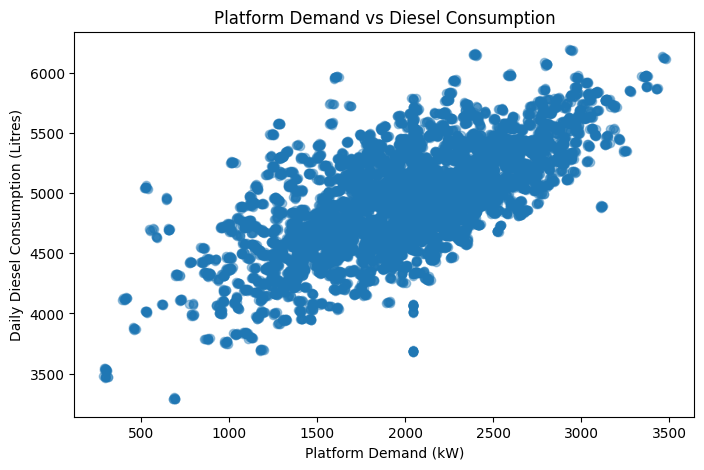

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df["platform_demand_kw"],
    df["daily_diesel_consumption_litres"],
    alpha=0.4
)

plt.xlabel("Platform Demand (kW)")
plt.ylabel("Daily Diesel Consumption (Litres)")
plt.title("Platform Demand vs Diesel Consumption")

plt.show()

In [40]:
print(
    df[
        ["platform_demand_kw",
         "daily_diesel_consumption_litres"]
    ].corr()
)

                                 platform_demand_kw  \
platform_demand_kw                         1.000000   
daily_diesel_consumption_litres            0.666027   

                                 daily_diesel_consumption_litres  
platform_demand_kw                                      0.666027  
daily_diesel_consumption_litres                         1.000000  


In [41]:
for i in range(1, 5):

    load = f"g{i}_load_pct"

    correlation = df[
        [load, "daily_diesel_consumption_litres"]
    ].corr().iloc[0, 1]

    print(
        f"{load} vs diesel correlation: "
        f"{correlation:.3f}"
    )

g1_load_pct vs diesel correlation: 0.372
g2_load_pct vs diesel correlation: 0.320
g3_load_pct vs diesel correlation: 0.291
g4_load_pct vs diesel correlation: 0.326


In [42]:
print(
    df[
        [
            "total_generator_power_kw",
            "daily_diesel_consumption_litres"
        ]
    ].corr()
)

                                 total_generator_power_kw  \
total_generator_power_kw                         1.000000   
daily_diesel_consumption_litres                  0.619966   

                                 daily_diesel_consumption_litres  
total_generator_power_kw                                0.619966  
daily_diesel_consumption_litres                         1.000000  


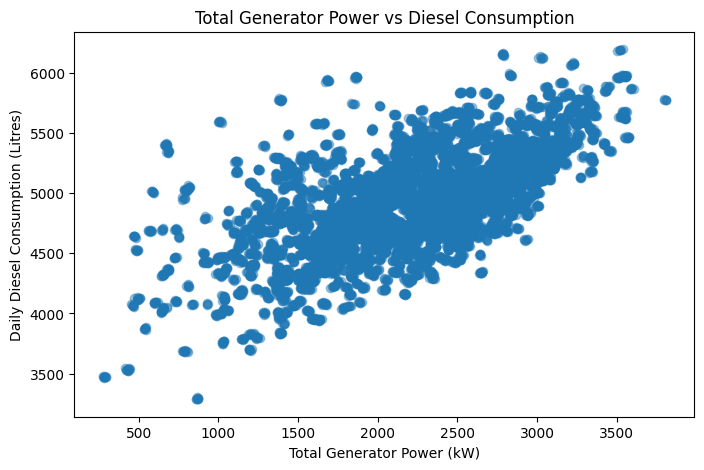

In [43]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["total_generator_power_kw"],
    df["daily_diesel_consumption_litres"],
    alpha=0.4
)

plt.xlabel("Total Generator Power (kW)")
plt.ylabel("Daily Diesel Consumption (Litres)")
plt.title("Total Generator Power vs Diesel Consumption")

plt.show()

In [44]:
environment_cols = [
    "ambient_temperature_c",
    "sea_temperature_c",
    "humidity_pct",
    "wind_speed_mps"
]

for col in environment_cols:

    correlation = df[
        [col, "daily_diesel_consumption_litres"]
    ].corr().iloc[0, 1]

    print(
        f"{col} vs diesel correlation: "
        f"{correlation:.3f}"
    )

ambient_temperature_c vs diesel correlation: 0.051
sea_temperature_c vs diesel correlation: 0.002
humidity_pct vs diesel correlation: 0.040
wind_speed_mps vs diesel correlation: 0.046


In [45]:
environment_cols = [
    "ambient_temperature_c",
    "sea_temperature_c",
    "humidity_pct",
    "wind_speed_mps"
]

for col in environment_cols:

    correlation = df[
        [col, "daily_diesel_consumption_litres"]
    ].corr().iloc[0, 1]

    print(
        f"{col} vs diesel correlation: "
        f"{correlation:.3f}"
    )

ambient_temperature_c vs diesel correlation: 0.051
sea_temperature_c vs diesel correlation: 0.002
humidity_pct vs diesel correlation: 0.040
wind_speed_mps vs diesel correlation: 0.046


In [46]:
target = "daily_diesel_consumption_litres"

numeric_cols = df.select_dtypes(include="number").columns

target_corr = (
    df[numeric_cols]
    .corr()[target]
    .sort_values(ascending=False)
)

print(target_corr)

daily_diesel_consumption_litres    1.000000
platform_demand_kw                 0.666027
total_generator_power_kw           0.619966
g1_load_pct                        0.371772
g1_power_kw                        0.358783
g4_power_kw                        0.332951
g4_load_pct                        0.325981
g2_load_pct                        0.319988
g2_power_kw                        0.319623
g3_load_pct                        0.290800
g3_power_kw                        0.272602
num_generators_on                  0.200842
power_difference                   0.077802
ambient_temperature_c              0.051122
wind_speed_mps                     0.045808
humidity_pct                       0.039722
sea_temperature_c                  0.001613
Name: daily_diesel_consumption_litres, dtype: float64


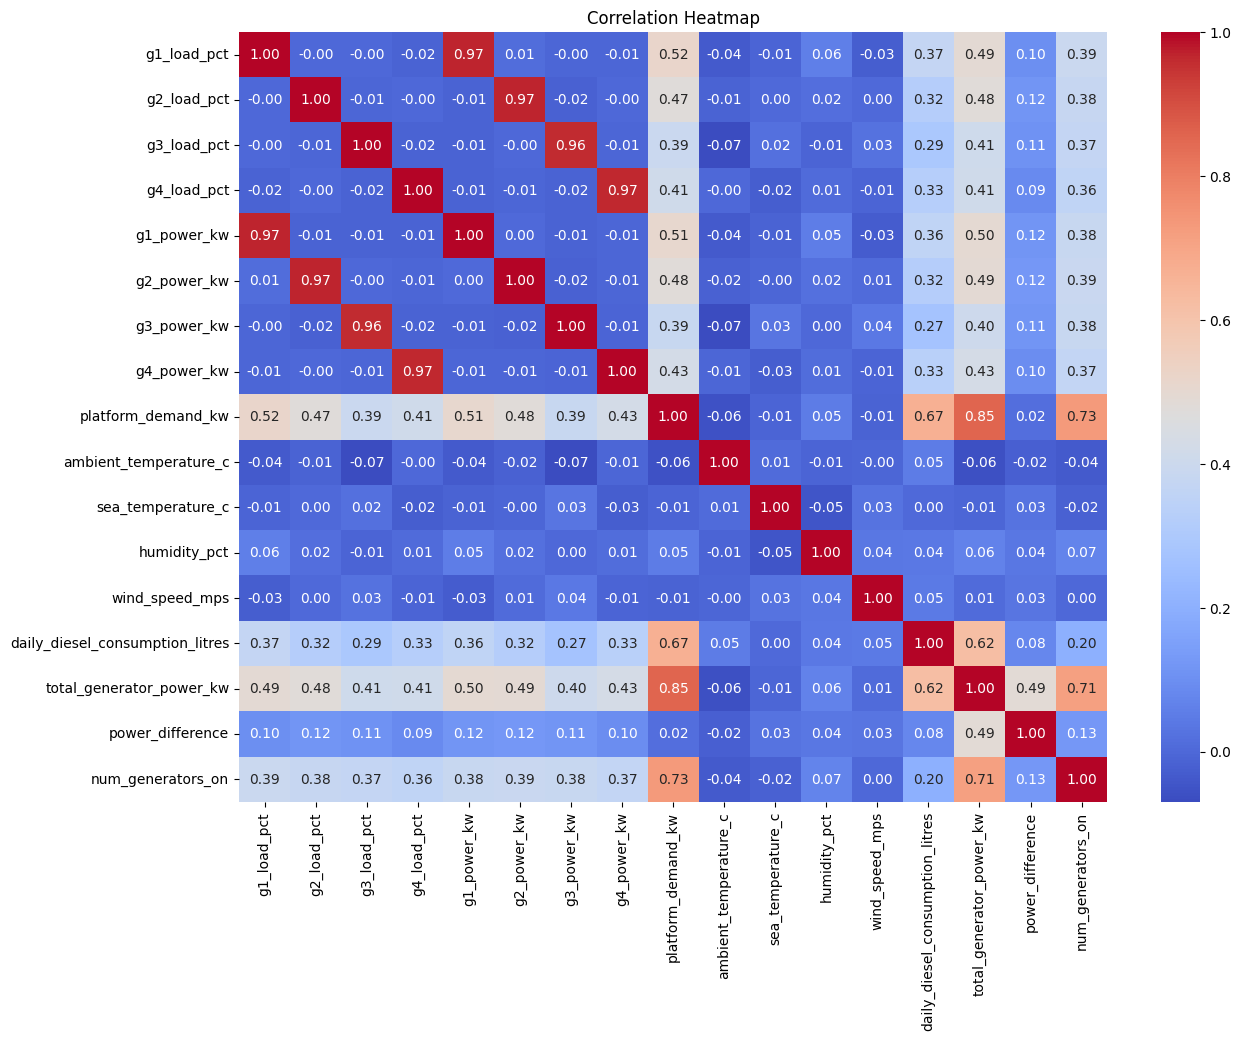

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

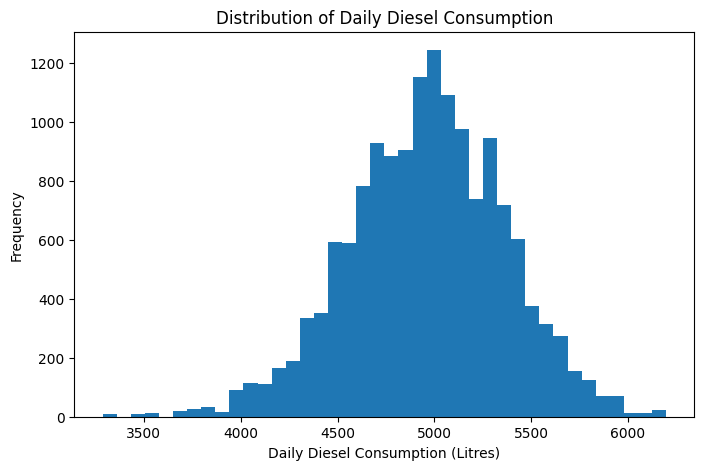

In [49]:
plt.figure(figsize=(8,5))

plt.hist(
    df["daily_diesel_consumption_litres"],
    bins=40
)

plt.xlabel("Daily Diesel Consumption (Litres)")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Diesel Consumption")

plt.show()

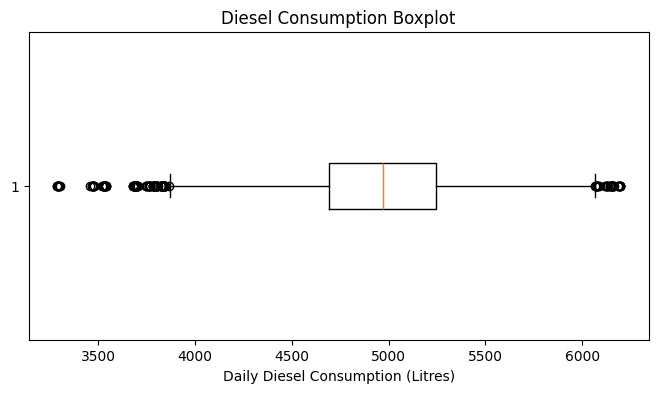

In [50]:
plt.figure(figsize=(8,4))

plt.boxplot(
    df["daily_diesel_consumption_litres"],
    vert=False
)

plt.xlabel("Daily Diesel Consumption (Litres)")
plt.title("Diesel Consumption Boxplot")

plt.show()

In [51]:
print(
    df[
        [
            "platform_demand_kw",
            "total_generator_power_kw",
            "num_generators_on",
            "power_difference"
        ]
    ].corr()
)

                          platform_demand_kw  total_generator_power_kw  \
platform_demand_kw                  1.000000                  0.854639   
total_generator_power_kw            0.854639                  1.000000   
num_generators_on                   0.729288                  0.713826   
power_difference                    0.016789                  0.487866   

                          num_generators_on  power_difference  
platform_demand_kw                 0.729288          0.016789  
total_generator_power_kw           0.713826          0.487866  
num_generators_on                  1.000000          0.125539  
power_difference                   0.125539          1.000000  


In [52]:
print(
    df[
        [
            "g1_load_pct",
            "g2_load_pct",
            "g3_load_pct",
            "g4_load_pct"
        ]
    ].corr()
)

             g1_load_pct  g2_load_pct  g3_load_pct  g4_load_pct
g1_load_pct     1.000000    -0.001105    -0.001921    -0.015038
g2_load_pct    -0.001105     1.000000    -0.005147    -0.001818
g3_load_pct    -0.001921    -0.005147     1.000000    -0.015039
g4_load_pct    -0.015038    -0.001818    -0.015039     1.000000


In [53]:
for load, status in zip(load_cols, status_cols):
    print("\n", load)
    print(df[df[load] < 0][status].value_counts())


 g1_load_pct
g1_status
OFF    864
Name: count, dtype: int64

 g2_load_pct
g2_status
OFF    772
Name: count, dtype: int64

 g3_load_pct
g3_status
OFF    746
Name: count, dtype: int64

 g4_load_pct
g4_status
OFF    798
Name: count, dtype: int64


In [54]:
features = [
    "g1_load_pct",
    "g2_load_pct",
    "g3_load_pct",
    "g4_load_pct",

    "g1_power_kw",
    "g2_power_kw",
    "g3_power_kw",
    "g4_power_kw",

    "platform_demand_kw",

    "ambient_temperature_c",
    "sea_temperature_c",
    "humidity_pct",
    "wind_speed_mps",

    "g1_status",
    "g2_status",
    "g3_status",
    "g4_status",

    "num_generators_on"
]

In [63]:
df_raw = pd.read_csv("/content/oil_platform_generator_optimization_synthetic_15057.csv")

print(df_raw.shape)
print(df_raw.isnull().sum().sum())

(15057, 18)
6919


In [64]:
target = "daily_diesel_consumption_litres"

features = [
    "g1_load_pct",
    "g2_load_pct",
    "g3_load_pct",
    "g4_load_pct",

    "g1_power_kw",
    "g2_power_kw",
    "g3_power_kw",
    "g4_power_kw",

    "platform_demand_kw",

    "ambient_temperature_c",
    "sea_temperature_c",
    "humidity_pct",
    "wind_speed_mps",

    "g1_status",
    "g2_status",
    "g3_status",
    "g4_status"
]

X = df_raw[features]
y = df_raw[target]

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 12045
Testing rows: 3012


In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "g1_load_pct",
    "g2_load_pct",
    "g3_load_pct",
    "g4_load_pct",

    "g1_power_kw",
    "g2_power_kw",
    "g3_power_kw",
    "g4_power_kw",

    "platform_demand_kw",

    "ambient_temperature_c",
    "sea_temperature_c",
    "humidity_pct",
    "wind_speed_mps"
]

categorical_features = [
    "g1_status",
    "g2_status",
    "g3_status",
    "g4_status"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [67]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['g1_load_pct', 'g2_load_pct',
                                                   'g3_load_pct', 'g4_load_pct',
                                                   'g1_power_kw', 'g2_power_kw',
                                                   'g3_power_kw', 'g4_power_kw',
                                                   'platform_demand_kw',
                                                   'ambient_temperature_c',
                                                   'sea_temperature_c',
                                                   'humidity_pct',
                                                   'wind_speed_mps']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['g1_status', 'g2_status',
                                                   'g3_status',
                                                   'g4_status'])])),
                ('model', LinearRegression())])

In [68]:
y_pred_linear = linear_model.predict(X_test)

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_linear)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression
MAE : 170.60733445602588
RMSE: 216.87835862443697
R²  : 0.7187025284664936


On average, the model's predicted diesel consumption differs from the actual value by approximately 170 litres.

In [70]:
for load, status in zip(load_cols, status_cols):
    print("\n", load)
    print(df[df[load] < 0][status].value_counts())


 g1_load_pct
g1_status
OFF    864
Name: count, dtype: int64

 g2_load_pct
g2_status
OFF    772
Name: count, dtype: int64

 g3_load_pct
g3_status
OFF    746
Name: count, dtype: int64

 g4_load_pct
g4_status
OFF    798
Name: count, dtype: int64


In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [72]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [73]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['g1_load_pct', 'g2_load_pct',
                                                   'g3_load_pct', 'g4_load_pct',
                                                   'g1_power_kw', 'g2_power_kw',
                                                   'g3_power_kw', 'g4_power_kw',
                                                   'platform_demand_kw',
                                                   'ambient_temperature_c',
                                                   'sea_temperature_c',
                                                   'humidity_pct',
                                                   'wind_speed_mps']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['g1_status', 'g2_status',
                                                   'g3_status',
                                                   'g4_status'])])),
                ('model', LinearRegression())])

In [74]:
y_pred_linear = linear_model.predict(X_test)

In [75]:
print("Actual values:")
print(y_test.head(10).values)

print("\nPredicted values:")
print(y_pred_linear[:10])

Actual values:
[5408.35034034 4775.81787066 4271.3497873  4639.929222   5015.74881487
 4376.24387901 4595.21702865 5364.38188718 4682.8053638  5540.08592548]

Predicted values:
[4985.90648083 4839.62498034 4422.90260794 5193.18065008 4861.85880979
 4537.5249285  4614.0942405  5351.35872902 4426.03857899 5178.04181195]


In [76]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_linear)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression
------------------
MAE : 170.60733445602588
RMSE: 216.87835862443697
R²  : 0.7187025284664936


means the model explains approximately 71% of the variation in the target under this evaluation setup.

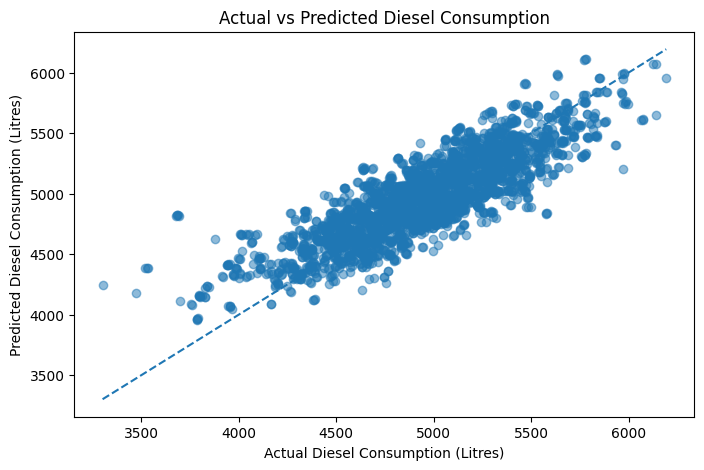

In [78]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5
)

min_value = min(y_test.min(), y_pred_linear.min())
max_value = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Diesel Consumption (Litres)")
plt.ylabel("Predicted Diesel Consumption (Litres)")
plt.title("Actual vs Predicted Diesel Consumption")

plt.show()

In [79]:
residuals = y_test - y_pred_linear

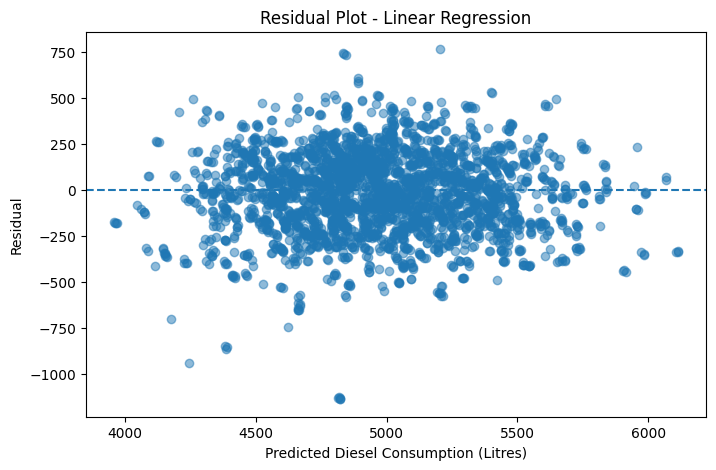

In [80]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_linear,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Diesel Consumption (Litres)")
plt.ylabel("Residual")
plt.title("Residual Plot - Linear Regression")

plt.show()

The model's predictions are off by about 171 litres on average.
Larger errors push RMSE to about 217 litres.
The model explains about 71.9% of the variation in diesel consumption.

In [81]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['g1_load_pct', 'g2_load_pct',
                                                   'g3_load_pct', 'g4_load_pct',
                                                   'g1_power_kw', 'g2_power_kw',
                                                   'g3_power_kw', 'g4_power_kw',
                                                   'platform_demand_kw',
                                                   'ambient_temperature_c',
                                                   'sea_temperature_c',
                                                   'humidity_pct',
                                                   'wind_speed_mps']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['g1_status', 'g2_status',
                                                   'g3_status',
                                                   'g4_status'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [82]:
y_pred_rf = rf_model.predict(X_test)

In [83]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
------------------
MAE : 15.98670186465823
RMSE: 29.983906305284346
R²  : 0.9946233741320343


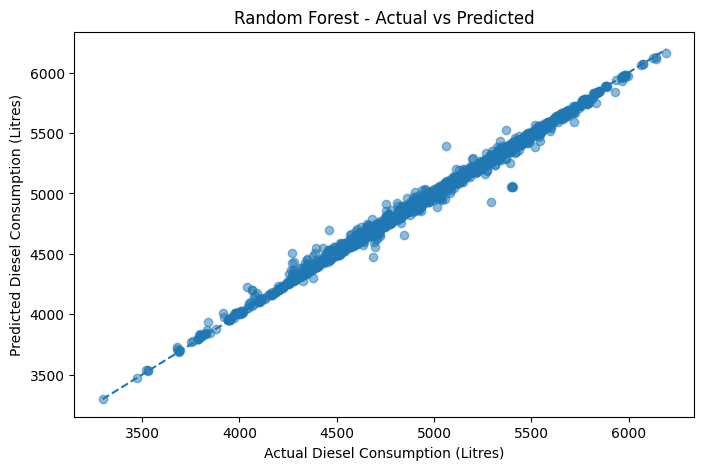

In [84]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Diesel Consumption (Litres)")
plt.ylabel("Predicted Diesel Consumption (Litres)")
plt.title("Random Forest - Actual vs Predicted")

plt.show()

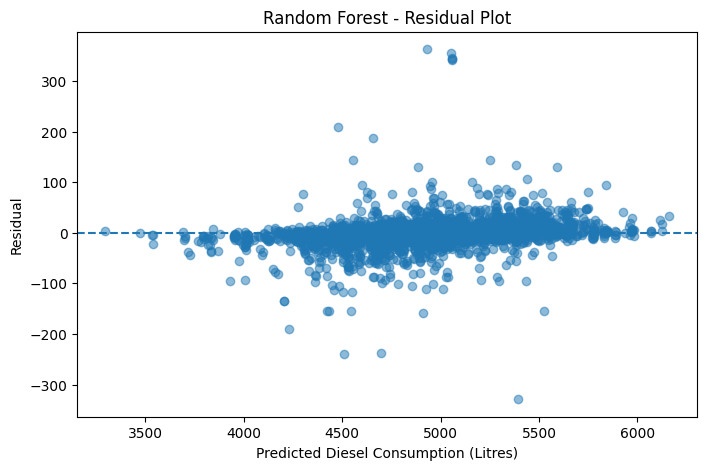

In [85]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_rf,
    residuals_rf,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Diesel Consumption (Litres)")
plt.ylabel("Residual")
plt.title("Random Forest - Residual Plot")

plt.show()

What this means

Random Forest's test-set predictions are off by only about 16 litres on average, compared with about 171 litres for Linear Regression.

And:

R² = 0.9946

means the model explains about 99.46% of the variation in the test target under this split.

That's excellent, but we should not immediately declare this our final model. The jump from 0.719 → 0.995 is large enough that we should check whether the dataset has a very strong synthetic/structural relationship between the features and target, and whether the model is overfitting.

In [87]:
y_pred_rf_train = rf_model.predict(X_train)

train_mae = mean_absolute_error(y_train, y_pred_rf_train)
train_rmse = np.sqrt(
    mean_squared_error(y_train, y_pred_rf_train)
)
train_r2 = r2_score(y_train, y_pred_rf_train)

print("Random Forest - Training")
print("-------------------------")
print("MAE :", train_mae)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

print("\nRandom Forest - Testing")
print("-----------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest - Training
-------------------------
MAE : 5.845739802106938
RMSE: 11.146727610808027
R²  : 0.9992349390998585

Random Forest - Testing
-----------------------
MAE : 15.98670186465823
RMSE: 29.983906305284346
R²  : 0.9946233741320343


In [88]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                       Feature  Importance
8      num__platform_demand_kw    0.469329
7             num__g4_power_kw    0.066768
2             num__g3_load_pct    0.053569
0             num__g1_load_pct    0.052372
3             num__g4_load_pct    0.051425
1             num__g2_load_pct    0.045066
4             num__g1_power_kw    0.042049
5             num__g2_power_kw    0.040352
6             num__g3_power_kw    0.039486
9   num__ambient_temperature_c    0.038798
11           num__humidity_pct    0.031200
12         num__wind_speed_mps    0.031117
10      num__sea_temperature_c    0.027443
17          cat__g3_status_OFF    0.002107
18           cat__g3_status_ON    0.001622
19          cat__g4_status_OFF    0.001598
15          cat__g2_status_OFF    0.001314
16           cat__g2_status_ON    0.001188
20           cat__g4_status_ON    0.001143
13          cat__g1_status_OFF    0.001066
14           cat__g1_status_ON    0.000987


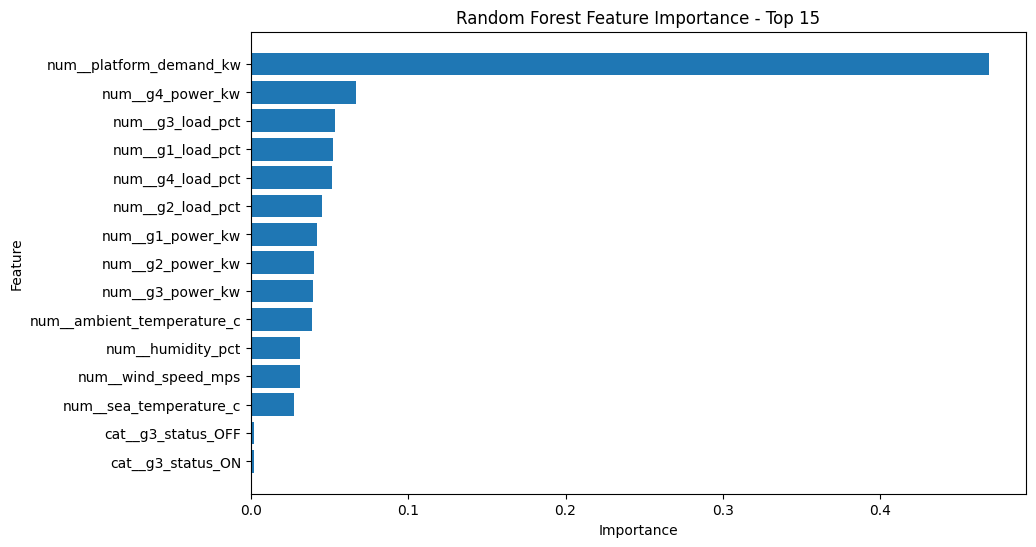

In [89]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance - Top 15")

plt.show()

In [91]:
from xgboost import XGBRegressor

In [92]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror",
            n_jobs=-1
        ))
    ]
)

In [93]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['g1_load_pct', 'g2_load_pct',
                                                   'g3_load_pct', 'g4_load_pct',
                                                   'g1_power_kw', 'g2_power_kw',
                                                   'g3_power_kw', 'g4_power_kw',
                                                   'platform_demand_kw',
                                                   'ambient_temperature_c',
                                                   'sea_temperature_c',
                                                   'humidity_pct',
                                                   'wind_speed_mps']),
                                                 ('ca...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [94]:
y_pred_xgb = xgb_model.predict(X_test)

In [95]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("------------------")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost
------------------
MAE : 48.481871466167654
RMSE: 66.26843176216508
R²  : 0.9737368521063633


| Model             |         MAE |        RMSE |         R² |
| ----------------- | ----------: | ----------: | ---------: |
| Linear Regression |    170.61 L |    216.88 L |     0.7187 |
| **Random Forest** | **15.99 L** | **29.98 L** | **0.9946** |
| XGBoost           |     48.48 L |     66.27 L |     0.9737 |


The difference is substantial:

Linear Regression → captures the broad relationship but misses nonlinear patterns.
XGBoost → captures nonlinear relationships much better.
Random Forest → performs best among these three under the current setup.


In [96]:
y_pred_rf_train = rf_model.predict(X_train)

train_mae_rf = mean_absolute_error(y_train, y_pred_rf_train)
train_rmse_rf = np.sqrt(
    mean_squared_error(y_train, y_pred_rf_train)
)
train_r2_rf = r2_score(y_train, y_pred_rf_train)

print("Random Forest - Training")
print("-------------------------")
print("MAE :", train_mae_rf)
print("RMSE:", train_rmse_rf)
print("R²  :", train_r2_rf)

print("\nRandom Forest - Testing")
print("-----------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest - Training
-------------------------
MAE : 5.8457398021069364
RMSE: 11.146727610808021
R²  : 0.9992349390998585

Random Forest - Testing
-----------------------
MAE : 15.98670186465823
RMSE: 29.983906305284346
R²  : 0.9946233741320343


The R² difference is:
0.99923 - 0.99462 = 0.00461

In [97]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                       Feature  Importance
8      num__platform_demand_kw    0.469329
7             num__g4_power_kw    0.066768
2             num__g3_load_pct    0.053569
0             num__g1_load_pct    0.052372
3             num__g4_load_pct    0.051425
1             num__g2_load_pct    0.045066
4             num__g1_power_kw    0.042049
5             num__g2_power_kw    0.040352
6             num__g3_power_kw    0.039486
9   num__ambient_temperature_c    0.038798
11           num__humidity_pct    0.031200
12         num__wind_speed_mps    0.031117
10      num__sea_temperature_c    0.027443
17          cat__g3_status_OFF    0.002107
18           cat__g3_status_ON    0.001622
19          cat__g4_status_OFF    0.001598
15          cat__g2_status_OFF    0.001314
16           cat__g2_status_ON    0.001188
20           cat__g4_status_ON    0.001143
13          cat__g1_status_OFF    0.001066
14           cat__g1_status_ON    0.000987


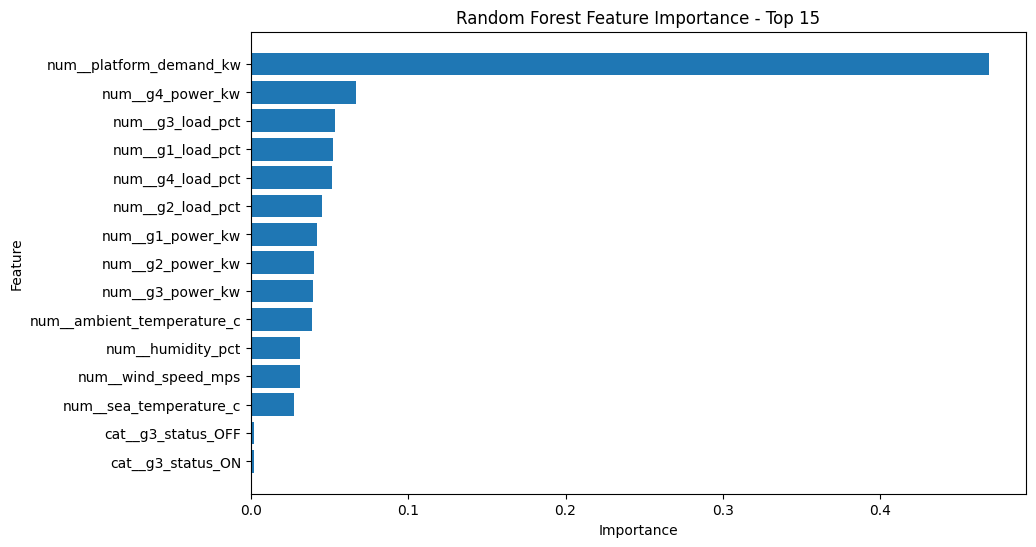

In [98]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance - Top 15")

plt.show()

In [99]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=5,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)

print("5-Fold Cross Validation")

print(
    "Mean MAE:",
    -cv_results["test_MAE"].mean()
)

print(
    "Mean RMSE:",
    -cv_results["test_RMSE"].mean()
)

print(
    "Mean R²:",
    cv_results["test_R2"].mean()
)

5-Fold Cross Validation
Mean MAE: 14.93406922220392
Mean RMSE: 27.838563120948756
Mean R²: 0.9951987233906779


In [102]:
print(
    df_raw[
        [
            "platform_demand_kw",
            "g1_power_kw",
            "g2_power_kw",
            "g3_power_kw",
            "g4_power_kw",
            "daily_diesel_consumption_litres"
        ]
    ].corr()["daily_diesel_consumption_litres"]
    .sort_values(ascending=False)
)

daily_diesel_consumption_litres    1.000000
platform_demand_kw                 0.677554
g1_power_kw                        0.369735
g4_power_kw                        0.339909
g2_power_kw                        0.324283
g3_power_kw                        0.278503
Name: daily_diesel_consumption_litres, dtype: float64


In [100]:
print(
    "R² Std:",
    cv_results["test_R2"].std()
)

R² Std: 0.0009218928530673967


In [101]:
y_pred_rf_train = rf_model.predict(X_train)

train_mae_rf = mean_absolute_error(y_train, y_pred_rf_train)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
train_r2_rf = r2_score(y_train, y_pred_rf_train)

print("Random Forest - Training")
print("MAE :", train_mae_rf)
print("RMSE:", train_rmse_rf)
print("R² :", train_r2_rf)

print("\nRandom Forest - Testing")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² :", r2_rf)

Random Forest - Training
MAE : 5.845739802106937
RMSE: 11.146727610808021
R² : 0.9992349390998585

Random Forest - Testing
MAE : 15.98670186465823
RMSE: 29.983906305284346
R² : 0.9946233741320343


Random Forest achieved an R² of 0.9946 on the held-out test set, with 5-fold cross-validation producing a mean R² of 0.9952.

In [103]:
df["total_generator_power_kw"]
df["power_difference"]
df["num_generators_on"]

,num_generators_on
0,4
1,3
2,4
3,3
4,3
...,...
15052,4
15053,2
15054,4
15055,4


In [104]:
df_raw["total_generator_power_kw"] = (
    df_raw["g1_power_kw"] +
    df_raw["g2_power_kw"] +
    df_raw["g3_power_kw"] +
    df_raw["g4_power_kw"]
)

df_raw["power_difference"] = (
    df_raw["total_generator_power_kw"]
    - df_raw["platform_demand_kw"]
)

df_raw["num_generators_on"] = (
    df_raw[
        ["g1_status", "g2_status", "g3_status", "g4_status"]
    ] == "ON"
).sum(axis=1)

In [105]:
features_engineered = [
    "g1_load_pct",
    "g2_load_pct",
    "g3_load_pct",
    "g4_load_pct",

    "g1_power_kw",
    "g2_power_kw",
    "g3_power_kw",
    "g4_power_kw",

    "platform_demand_kw",

    "ambient_temperature_c",
    "sea_temperature_c",
    "humidity_pct",
    "wind_speed_mps",

    "g1_status",
    "g2_status",
    "g3_status",
    "g4_status",

    "num_generators_on",
    "total_generator_power_kw",
    "power_difference"
]

X_eng = df_raw[features_engineered]
y_eng = df_raw[target]

In [106]:
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng,
    y_eng,
    test_size=0.20,
    random_state=42
)

In [107]:
numeric_features_eng = [
    "g1_load_pct",
    "g2_load_pct",
    "g3_load_pct",
    "g4_load_pct",

    "g1_power_kw",
    "g2_power_kw",
    "g3_power_kw",
    "g4_power_kw",

    "platform_demand_kw",

    "ambient_temperature_c",
    "sea_temperature_c",
    "humidity_pct",
    "wind_speed_mps",

    "num_generators_on",
    "total_generator_power_kw",
    "power_difference"
]

categorical_features_eng = [
    "g1_status",
    "g2_status",
    "g3_status",
    "g4_status"
]

In [108]:
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng,
    y_eng,
    test_size=0.20,
    random_state=42
)

In [109]:
numeric_features_eng = [
    "g1_load_pct",
    "g2_load_pct",
    "g3_load_pct",
    "g4_load_pct",

    "g1_power_kw",
    "g2_power_kw",
    "g3_power_kw",
    "g4_power_kw",

    "platform_demand_kw",

    "ambient_temperature_c",
    "sea_temperature_c",
    "humidity_pct",
    "wind_speed_mps",

    "num_generators_on",
    "total_generator_power_kw",
    "power_difference"
]

categorical_features_eng = [
    "g1_status",
    "g2_status",
    "g3_status",
    "g4_status"
]

In [110]:
numeric_transformer_eng = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer_eng = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_eng = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_eng, numeric_features_eng),
        ("cat", categorical_transformer_eng, categorical_features_eng)
    ]
)

In [111]:
rf_eng = Pipeline(
    steps=[
        ("preprocessor", preprocessor_eng),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_eng.fit(X_train_eng, y_train_eng)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['g1_load_pct', 'g2_load_pct',
                                                   'g3_load_pct', 'g4_load_pct',
                                                   'g1_power_kw', 'g2_power_kw',
                                                   'g3_power_kw', 'g4_power_kw',
                                                   'platform_demand_kw',
                                                   'ambient_temperature_c',
                                                   'sea_temperature_c',
                                                   'humidity_pct',
                                                   'wind_speed_mps',
                                                   'num_generators_on',
                                                   'total_generator_power_kw',
                                                   'power_difference']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['g1_status', 'g2_status',
                                                   'g3_status',
                                                   'g4_status'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [112]:
y_pred_eng = rf_eng.predict(X_test_eng)

In [113]:
mae_eng = mean_absolute_error(y_test_eng, y_pred_eng)

rmse_eng = np.sqrt(
    mean_squared_error(y_test_eng, y_pred_eng)
)

r2_eng = r2_score(y_test_eng, y_pred_eng)

print("Random Forest + Engineered Features")
print("-----------------------------------")
print("MAE :", mae_eng)
print("RMSE:", rmse_eng)
print("R²  :", r2_eng)

Random Forest + Engineered Features
-----------------------------------
MAE : 15.507934281169046
RMSE: 29.055930449004695
R²  : 0.9949510279387567


In [114]:
from sklearn.ensemble import RandomForestRegressor

rf_tuned_base = Pipeline(
    steps=[
        ("preprocessor", preprocessor_eng),
        ("model", RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [115]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 15, 20, 25, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.7, 1.0]
}

In [116]:
random_search = RandomizedSearchCV(
    estimator=rf_tuned_base,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_eng, y_train_eng)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['g1_load_pct',
                                                                                'g2_load_pct',
                                                                                'g3_load_pct',
                                                                                'g4_load_pct',
                                                                                'g1_power_kw',
                                                                                'g2_power_kw',
                                                                                'g3_power_kw',
                                                                                'g4_power_kw',
                                                                                'platform_demand_kw',
                                                                                'ambient_temperature_c',
                                                                                'sea_temperature_c',
                                                                                'hum...
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 15, 20,
                                                             25, 30],
                                        'model__max_features': ['sqrt', 'log2',
                                                                0.7, 1.0],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [117]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV MAE:")
print(-random_search.best_score_)

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 30}

Best CV MAE:
20.445549830186525


In [118]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_eng)

mae_tuned = mean_absolute_error(
    y_test_eng,
    y_pred_tuned
)

rmse_tuned = np.sqrt(
    mean_squared_error(y_test_eng, y_pred_tuned)
)

r2_tuned = r2_score(
    y_test_eng,
    y_pred_tuned
)

print("\nTuned Random Forest")
print("-------------------")
print("MAE :", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)


Tuned Random Forest
-------------------
MAE : 16.819158832948094
RMSE: 26.992956956143136
R²  : 0.9956425308881588


MAE  = 16.82 litres
RMSE = 26.99 litres
R²   = 0.99564

After hyperparameter tuning, the model achieved an R² of 0.9956 and RMSE of 26.99 litres. MAE increased slightly compared with the untuned engineered Random Forest, so I evaluated multiple metrics rather than relying on a single metric

In [119]:
from sklearn.model_selection import cross_validate
import numpy as np

cv_results = cross_validate(
    best_rf,
    X_train_eng,
    y_train_eng,
    cv=5,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)

print("5-Fold Cross-Validation Results")
print("--------------------------------")

print("Mean MAE :", -cv_results["test_MAE"].mean())
print("Mean RMSE:", -cv_results["test_RMSE"].mean())
print("Mean R²  :", cv_results["test_R2"].mean())

print("\nStandard Deviation")
print("------------------")
print("MAE :", cv_results["test_MAE"].std())
print("RMSE:", cv_results["test_RMSE"].std())
print("R²  :", cv_results["test_R2"].std())

5-Fold Cross-Validation Results
--------------------------------
Mean MAE : 20.44554983018652
Mean RMSE: 33.018605120886086
Mean R²  : 0.9932202855347333

Standard Deviation
------------------
MAE : 0.8216836366702744
RMSE: 2.8388537348218374
R²  : 0.001271870285987634


<!-- Final Model: Tuned Random Forest Regressor

Test Performance
MAE  : 16.82 litres
RMSE : 26.99 litres
R²   : 0.9956

5-Fold Cross-Validation
MAE  : 20.45 litres
RMSE : 33.02 litres
R²   : 0.9932 ± 0.0013 -->

#Final Model: Tuned Random Forest Regressor

#Test Performance
MAE  : 16.82 litres

RMSE : 26.99 litres

R²   : 0.9956

#5-Fold Cross-Validation
MAE  : 20.45 litres

RMSE : 33.02 litres

R²   : 0.9932 ± 0.0013

Next step: Actual vs Predicted

Now we should visually check whether the model's predictions track the actual diesel consumption.

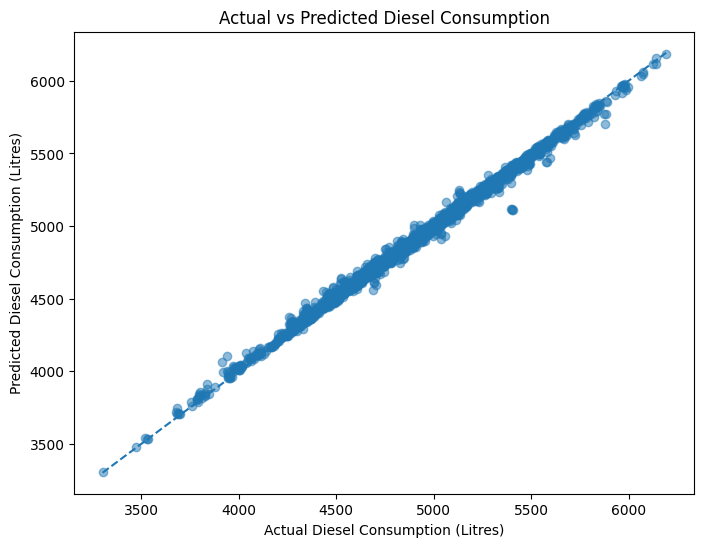

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_eng,
    y_pred_tuned,
    alpha=0.5
)

# Perfect prediction line
plt.plot(
    [y_test_eng.min(), y_test_eng.max()],
    [y_test_eng.min(), y_test_eng.max()],
    linestyle="--"
)

plt.xlabel("Actual Diesel Consumption (Litres)")
plt.ylabel("Predicted Diesel Consumption (Litres)")
plt.title("Actual vs Predicted Diesel Consumption")

plt.show()

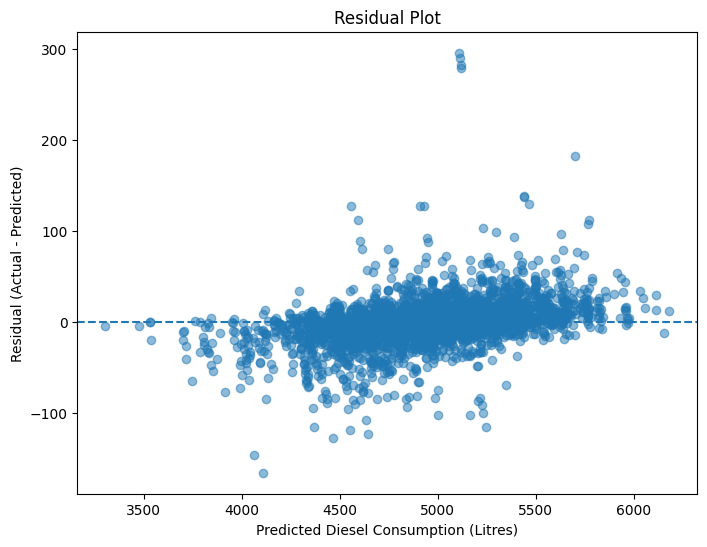

In [121]:
residuals = y_test_eng - y_pred_tuned

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_tuned,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Diesel Consumption (Litres)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

1. Actual vs Predicted — very strong

Your plot shows the points tightly following the diagonal Actual = Predicted line.

That is consistent with your test metrics:

MAE  = 16.82 litres
RMSE = 26.99 litres
R²   = 0.99564

So the model is predicting diesel consumption very closely for most test observations.

For your presentation, you can say:

"The actual-versus-predicted plot shows that the Random Forest predictions closely follow the ideal diagonal line, indicating strong predictive performance."

Don't say "100% accurate" or "perfect prediction."

2. Residual plot — good, but there is something interesting

Most residuals are concentrated around zero, which is what we want.

However, there is a noticeable pattern:

At lower predicted consumption, residuals are generally closer to zero.
Around the middle/high consumption range, the spread increases.
There are several positive residual outliers reaching around +300 L.
There are also negative residuals reaching roughly −170 L.

Remember:

Residual = Actual - Predicted

Therefore:

Positive residual → model predicted too low
Negative residual → model predicted too high

The residuals aren't completely uniform, so I wouldn't claim the model has "no errors" or "perfect residuals."

A good interview explanation would be:

"The residuals are mostly centered around zero, indicating that the model does not show a strong systematic bias. However, a few larger residuals are visible, particularly at higher consumption levels, suggesting some observations are harder to predict."

That's accurate.

In [122]:
residual_df = pd.DataFrame({
    "Actual": y_test_eng.values,
    "Predicted": y_pred_tuned,
    "Residual": residuals
})

residual_df["Absolute_Error"] = abs(residual_df["Residual"])

residual_df = residual_df.sort_values(
    "Absolute_Error",
    ascending=False
)

print(residual_df.head(10))

            Actual    Predicted    Residual  Absolute_Error
2406   5407.582774  5111.880856  295.701919      295.701919
3206   5402.456496  5112.676279  289.780218      289.780218
388    5403.234637  5120.681446  282.553191      282.553191
9775   5396.711941  5117.577037  279.134905      279.134905
5152   5881.762718  5699.840561  181.922157      181.922157
1697   3941.799101  4107.751766 -165.952664      165.952664
6860   3914.815283  4061.546970 -146.731688      146.731688
9876   5577.685774  5438.996336  138.689438      138.689438
13301  5580.815637  5443.790387  137.025250      137.025250
2133   5594.915040  5465.905451  129.009589      129.009589


In [123]:
print("Maximum Absolute Error:",
      residual_df["Absolute_Error"].max())

print("Mean Absolute Error:",
      residual_df["Absolute_Error"].mean())

print("Median Absolute Error:",
      residual_df["Absolute_Error"].median())

Maximum Absolute Error: 295.7019185885438
Mean Absolute Error: 16.819158832948098
Median Absolute Error: 10.410296810678119


In [124]:
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

importances = best_rf.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance_df.head(15))

                          Feature  Importance
8         num__platform_demand_kw    0.198184
14  num__total_generator_power_kw    0.107728
7                num__g4_power_kw    0.077799
0                num__g1_load_pct    0.076975
4                num__g1_power_kw    0.076905
5                num__g2_power_kw    0.065086
2                num__g3_load_pct    0.060592
3                num__g4_load_pct    0.060327
1                num__g2_load_pct    0.059295
6                num__g3_power_kw    0.049754
9      num__ambient_temperature_c    0.027249
12            num__wind_speed_mps    0.023865
13         num__num_generators_on    0.023541
15          num__power_difference    0.022880
11              num__humidity_pct    0.022867


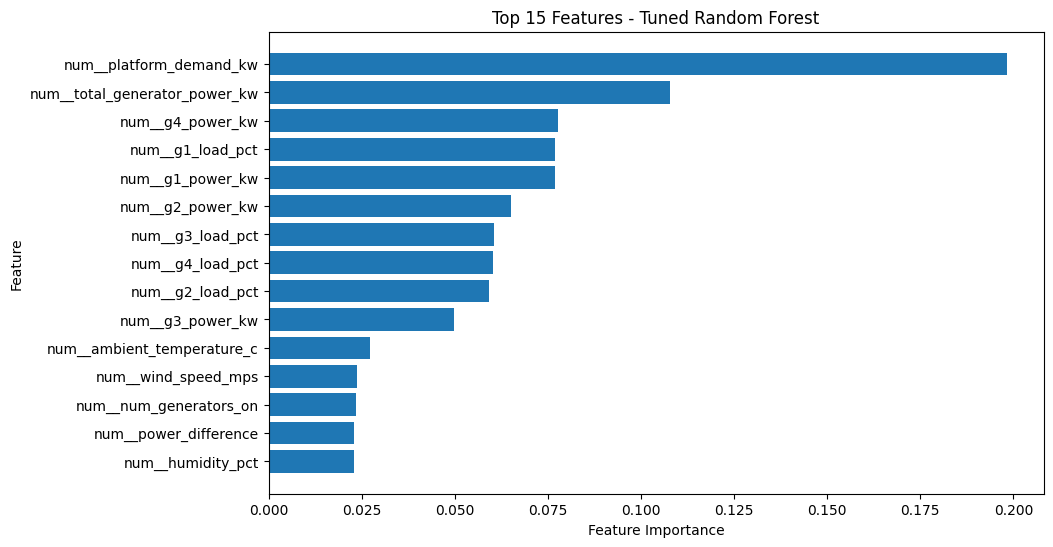

In [125]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Tuned Random Forest")

plt.show()

Platform demand is the most important predictor of daily diesel consumption.

In [126]:
df_raw["total_generator_power_kw"] = (
    df_raw["g1_power_kw"] +
    df_raw["g2_power_kw"] +
    df_raw["g3_power_kw"] +
    df_raw["g4_power_kw"]
)

In [127]:
feature_importance_df["Feature"] = (
    feature_importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

print(feature_importance_df.head(15))

                     Feature  Importance
8         platform_demand_kw    0.198184
14  total_generator_power_kw    0.107728
7                g4_power_kw    0.077799
0                g1_load_pct    0.076975
4                g1_power_kw    0.076905
5                g2_power_kw    0.065086
2                g3_load_pct    0.060592
3                g4_load_pct    0.060327
1                g2_load_pct    0.059295
6                g3_power_kw    0.049754
9      ambient_temperature_c    0.027249
12            wind_speed_mps    0.023865
13         num_generators_on    0.023541
15          power_difference    0.022880
11              humidity_pct    0.022867


In [128]:
residual_df = pd.DataFrame({
    "Actual": y_test_eng.values,
    "Predicted": y_pred_tuned,
    "Residual": residuals
})

residual_df["Absolute_Error"] = abs(residual_df["Residual"])

residual_df = residual_df.sort_values(
    "Absolute_Error",
    ascending=False
)

print(residual_df.head(10))

            Actual    Predicted    Residual  Absolute_Error
2406   5407.582774  5111.880856  295.701919      295.701919
3206   5402.456496  5112.676279  289.780218      289.780218
388    5403.234637  5120.681446  282.553191      282.553191
9775   5396.711941  5117.577037  279.134905      279.134905
5152   5881.762718  5699.840561  181.922157      181.922157
1697   3941.799101  4107.751766 -165.952664      165.952664
6860   3914.815283  4061.546970 -146.731688      146.731688
9876   5577.685774  5438.996336  138.689438      138.689438
13301  5580.815637  5443.790387  137.025250      137.025250
2133   5594.915040  5465.905451  129.009589      129.009589


In [129]:
worst_indices = [2406, 3206, 388, 9775]

print(
    df_raw.loc[
        worst_indices,
        [
            "g1_load_pct", "g2_load_pct",
            "g3_load_pct", "g4_load_pct",
            "g1_power_kw", "g2_power_kw",
            "g3_power_kw", "g4_power_kw",
            "platform_demand_kw",
            "ambient_temperature_c",
            "sea_temperature_c",
            "humidity_pct",
            "wind_speed_mps",
            "g1_status", "g2_status",
            "g3_status", "g4_status"
        ]
    ]
)

      g1_load_pct  g2_load_pct  g3_load_pct  g4_load_pct  g1_power_kw  \
2406    88.602375    50.313960    -0.338318     0.097104  1075.128703   
3206    88.805752    49.957489    -0.042554    -0.425503  1073.426271   
388     88.874488    50.195519     0.000000     0.000000  1066.493857   
9775    88.451270    50.076124     0.102373    -0.277087  1068.680705   

      g2_power_kw  g3_power_kw  g4_power_kw  platform_demand_kw  \
2406   608.638731     4.146625    -5.955717         1389.090380   
3206   602.771048    -4.176416    -9.311028         1386.513106   
388    602.346230     0.000000     0.000000         1391.235090   
9775   598.704655    -0.479901     2.492563         1382.473948   

      ambient_temperature_c  sea_temperature_c  humidity_pct  wind_speed_mps  \
2406              29.841299          16.619384     71.474164       19.801890   
3206              29.798953          16.670757     71.634562       19.598561   
388               29.708023          16.741682     71.4614

In [130]:
config_analysis = df_raw.copy()

config_analysis["generator_configuration"] = (
    config_analysis["g1_status"] + "_" +
    config_analysis["g2_status"] + "_" +
    config_analysis["g3_status"] + "_" +
    config_analysis["g4_status"]
)

config_summary = (
    config_analysis
    .groupby("generator_configuration")
    ["daily_diesel_consumption_litres"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("count", ascending=False)
)

print(config_summary)

                         count         mean       median          min  \
generator_configuration                                                 
ON_ON_ON_ON               8764  5016.729702  5006.804310  3943.772895   
ON_ON_ON_OFF              1386  4912.577023  4957.209422  3690.110933   
ON_OFF_ON_ON              1313  4925.926954  4906.071472  3957.150533   
OFF_ON_ON_ON              1265  4845.928779  4824.807783  3749.285278   
ON_ON_OFF_ON              1205  4968.047828  4966.235104  3783.176637   
OFF_ON_OFF_ON              272  4800.453690  4840.100533  3678.232143   
OFF_OFF_ON_ON              183  4836.509591  4777.766973  4080.958296   
ON_OFF_ON_OFF              155  4812.719629  4773.961645  3977.652391   
ON_OFF_OFF_ON              141  4790.859716  4800.415698  4038.260697   
OFF_ON_ON_OFF              135  4710.122522  4684.502867  4022.640013   
ON_ON_OFF_OFF              128  4744.373493  4819.576563  3286.661154   
OFF_ON_OFF_OFF              40  3913.312637  3541.7

In [131]:
config_demand = (
    config_analysis
    .groupby("generator_configuration")
    .agg(
        observations=("daily_diesel_consumption_litres", "size"),
        avg_demand=("platform_demand_kw", "mean"),
        min_demand=("platform_demand_kw", "min"),
        max_demand=("platform_demand_kw", "max"),
        avg_diesel=("daily_diesel_consumption_litres", "mean")
    )
    .sort_values("observations", ascending=False)
)

print(config_demand)

                         observations   avg_demand   min_demand   max_demand  \
generator_configuration                                                        
ON_ON_ON_ON                      8764  2318.378026  1302.907225  3481.686542   
ON_ON_ON_OFF                     1386  1752.301043  1091.293136  2603.071462   
ON_OFF_ON_ON                     1313  1695.936773   962.930139  2460.419706   
OFF_ON_ON_ON                     1265  1648.551245   969.689371  2407.735440   
ON_ON_OFF_ON                     1205  1801.337197   858.237407  2513.421099   
OFF_ON_OFF_ON                     272  1203.126219   772.650344  1590.822008   
OFF_OFF_ON_ON                     183  1138.902328   832.552137  1523.014908   
ON_OFF_ON_OFF                     155  1198.382332   612.742185  1625.609361   
ON_OFF_OFF_ON                     141  1159.864352   769.937545  1592.895037   
OFF_ON_ON_OFF                     135  1186.542790   948.160818  1417.197358   
ON_ON_OFF_OFF                     128  1

In [134]:
config_analysis["demand_band"] = pd.cut(
    config_analysis["platform_demand_kw"],
    bins=[0, 500, 1000, 1500, 2000, 2500, 3000, 3500],
    labels=[
        "0-500",
        "500-1000",
        "1000-1500",
        "1500-2000",
        "2000-2500",
        "2500-3000",
        "3000-3500"
    ]
)

demand_config_summary = (
    config_analysis
    .groupby(
        ["demand_band", "generator_configuration"],
        observed=True
    )
    .agg(
        observations=("daily_diesel_consumption_litres", "size"),
        avg_diesel=("daily_diesel_consumption_litres", "mean"),
        median_diesel=("daily_diesel_consumption_litres", "median")
    )
    .reset_index()
)

print(demand_config_summary.to_string(index=False))

demand_band generator_configuration  observations  avg_diesel  median_diesel
      0-500          OFF_OFF_ON_OFF             8 3876.300659    3876.234328
      0-500          OFF_ON_OFF_OFF            22 3508.288930    3526.264536
      0-500          ON_OFF_OFF_OFF            12 4123.668165    4123.513847
   500-1000          OFF_OFF_OFF_ON             9 4016.740047    4016.809383
   500-1000          OFF_OFF_ON_OFF            17 5015.888222    5044.508422
   500-1000           OFF_OFF_ON_ON            37 4382.899310    4420.555598
   500-1000          OFF_ON_OFF_OFF            18 4408.341614    4325.295748
   500-1000           OFF_ON_OFF_ON            67 4452.700269    4450.104803
   500-1000           OFF_ON_ON_OFF            18 4105.929072    4096.953733
   500-1000            OFF_ON_ON_ON            11 3760.373076    3762.532505
   500-1000          ON_OFF_OFF_OFF            16 4698.646068    4697.228715
   500-1000           ON_OFF_OFF_ON            23 4327.263972    4322.234834

In [135]:
config_capacity = {
    "ON_ON_ON_ON": 4400,
    "ON_ON_ON_OFF": 3400,
    "ON_ON_OFF_ON": 3400,
    "ON_OFF_ON_ON": 3200,
    "OFF_ON_ON_ON": 3200,
    "ON_ON_OFF_OFF": 2400,
    "ON_OFF_ON_OFF": 2200,
    "ON_OFF_OFF_ON": 2200,
    "OFF_ON_ON_OFF": 2200,
    "OFF_ON_OFF_ON": 2200,
    "OFF_OFF_ON_ON": 2000
}

config_feasibility = (
    config_analysis
    .groupby("generator_configuration")
    .agg(
        observations=("platform_demand_kw", "size"),
        min_demand=("platform_demand_kw", "min"),
        max_demand=("platform_demand_kw", "max")
    )
    .reset_index()
)

config_feasibility["approx_capacity_kw"] = (
    config_feasibility["generator_configuration"]
    .map(config_capacity)
)

config_feasibility["capacity_margin_kw"] = (
    config_feasibility["approx_capacity_kw"]
    - config_feasibility["max_demand"]
)

print(
    config_feasibility
    .sort_values("observations", ascending=False)
    .to_string(index=False)
)

generator_configuration  observations  min_demand  max_demand  approx_capacity_kw  capacity_margin_kw
            ON_ON_ON_ON          8764 1302.907225 3481.686542              4400.0          918.313458
           ON_ON_ON_OFF          1386 1091.293136 2603.071462              3400.0          796.928538
           ON_OFF_ON_ON          1313  962.930139 2460.419706              3200.0          739.580294
           OFF_ON_ON_ON          1265  969.689371 2407.735440              3200.0          792.264560
           ON_ON_OFF_ON          1205  858.237407 2513.421099              3400.0          886.578901
          OFF_ON_OFF_ON           272  772.650344 1590.822008              2200.0          609.177992
          OFF_OFF_ON_ON           183  832.552137 1523.014908              2000.0          476.985092
          ON_OFF_ON_OFF           155  612.742185 1625.609361              2200.0          574.390639
          ON_OFF_OFF_ON           141  769.937545 1592.895037              2200.0 

#The analysis successfully developed a Random Forest regression model capable of predicting daily diesel consumption from generator operating, load, power-demand, and environmental variables. The tuned model achieved an R² of 0.9956 on the test set, with an MAE of 16.82 litres and RMSE of 26.99 litres. Five-fold cross-validation also showed consistent performance (R² = 0.9932 ± 0.0013). Platform demand was the most influential predictor, followed by generator power/load-related variables.

The analysis also showed that generator operating configurations and platform demand are strongly related to diesel consumption. However, configuration-level comparisons must account for differences in demand ranges and the limited observations available for some configurations. Therefore, the results support using the model as a fuel-consumption prediction and decision-support tool rather than claiming a universally optimal generator configuration.

| Metric         |              Result |
| -------------- | ------------------: |
| Test MAE       |         **16.82 L** |
| Test RMSE      |         **26.99 L** |
| Test R²        |          **0.9956** |
| 5-Fold CV MAE  |         **20.45 L** |
| 5-Fold CV RMSE |         **33.02 L** |
| 5-Fold CV R²   | **0.9932 ± 0.0013** |
